In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/Churn_Modelling.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Churn rate:", df['Exited'].mean()*100, "%")
df.head()

Dataset loaded successfully
Shape: (10000, 14)
Churn rate: 20.369999999999997 %


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


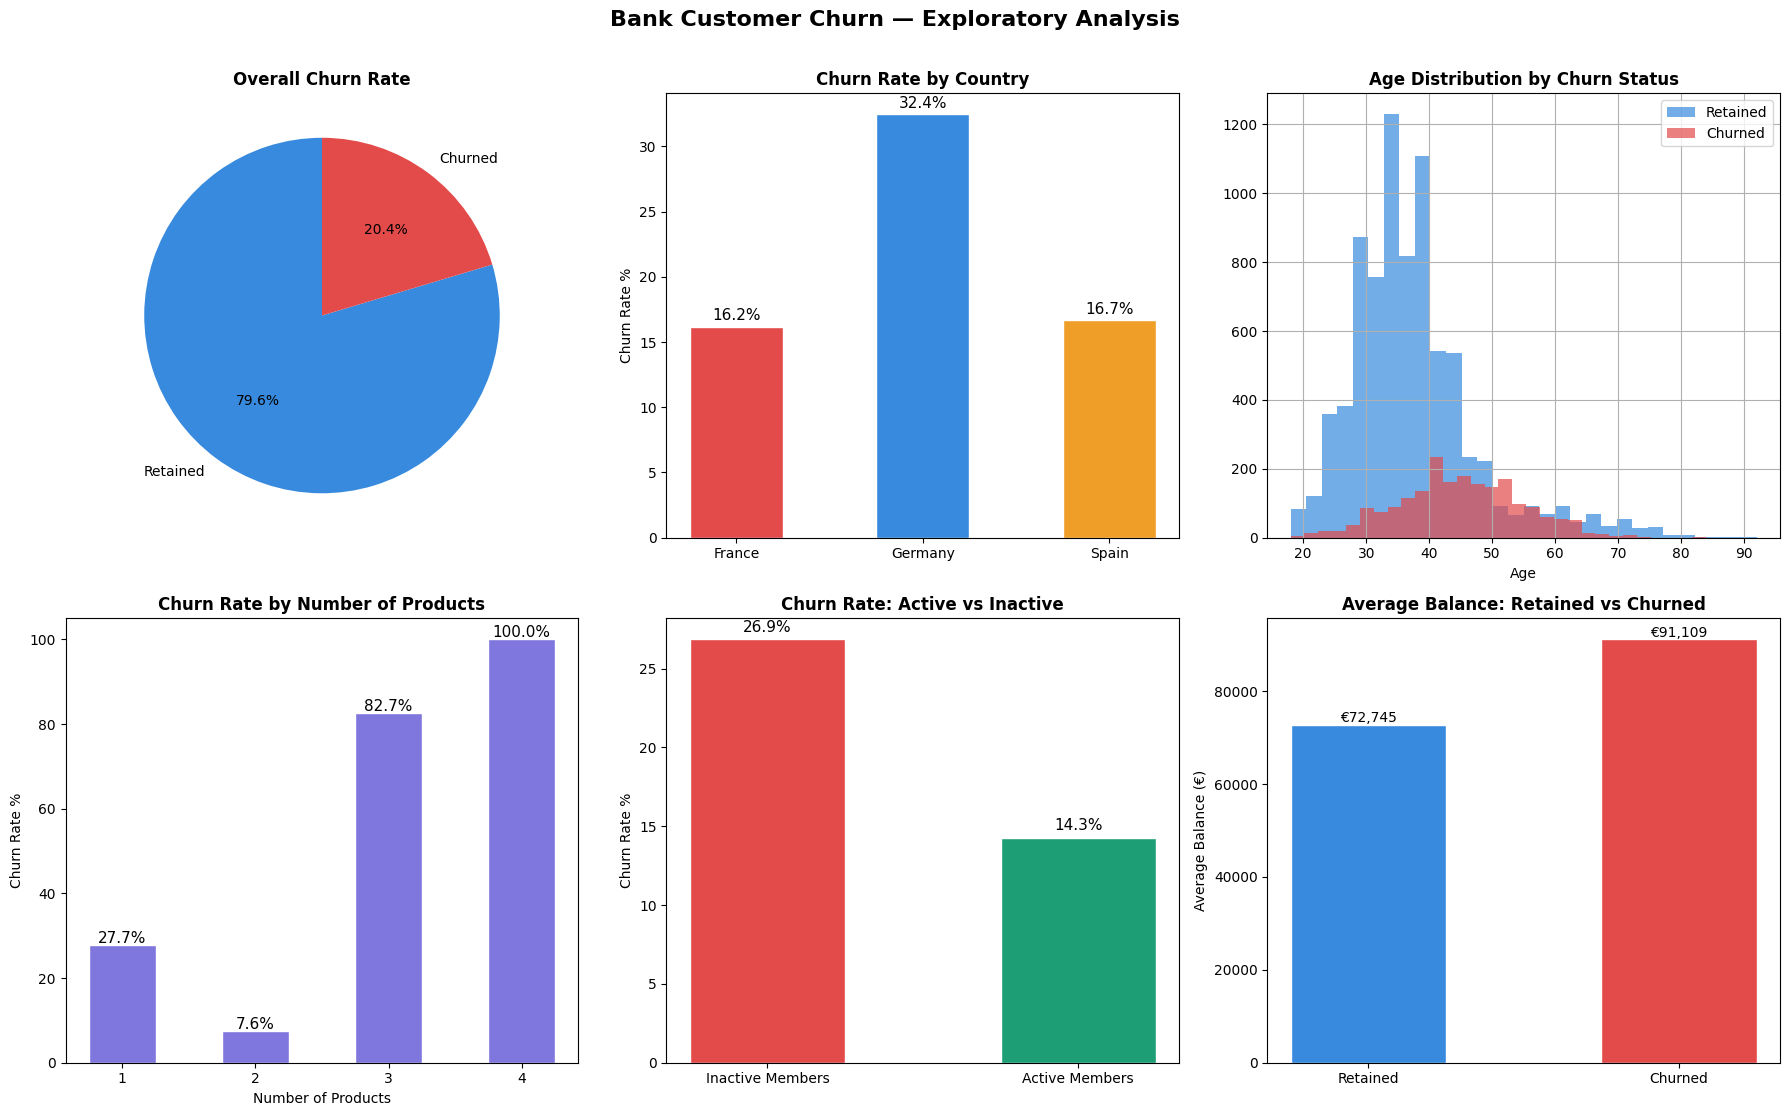

Charts saved as churn_eda_charts.png


In [5]:
# Cell 2 — All EDA charts
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Bank Customer Churn — Exploratory Analysis',
             fontsize=16, fontweight='bold', y=1.01)

# Chart 1: Overall churn split (donut)
churn_counts = df['Exited'].value_counts()
axes[0,0].pie(churn_counts,
              labels=['Retained', 'Churned'],
              autopct='%1.1f%%',
              colors=['#378ADD', '#E24B4A'],
              startangle=90)
axes[0,0].set_title('Overall Churn Rate', fontweight='bold')

# Chart 2: Churn rate by Geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
bars = axes[0,1].bar(geo_churn.index,
                     geo_churn.values,
                     color=['#E24B4A', '#378ADD', '#EF9F27'],
                     edgecolor='white', width=0.5)
axes[0,1].set_title('Churn Rate by Country', fontweight='bold')
axes[0,1].set_ylabel('Churn Rate %')
for bar, val in zip(bars, geo_churn.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center', fontsize=11)

# Chart 3: Age distribution by churn
df[df['Exited']==0]['Age'].hist(ax=axes[0,2], bins=30,
                                  color='#378ADD', alpha=0.7,
                                  label='Retained')
df[df['Exited']==1]['Age'].hist(ax=axes[0,2], bins=30,
                                  color='#E24B4A', alpha=0.7,
                                  label='Churned')
axes[0,2].set_title('Age Distribution by Churn Status', fontweight='bold')
axes[0,2].set_xlabel('Age')
axes[0,2].legend()

# Chart 4: Churn by number of products
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
bars2 = axes[1,0].bar(prod_churn.index.astype(str),
                      prod_churn.values,
                      color='#7F77DD', edgecolor='white', width=0.5)
axes[1,0].set_title('Churn Rate by Number of Products', fontweight='bold')
axes[1,0].set_xlabel('Number of Products')
axes[1,0].set_ylabel('Churn Rate %')
for bar, val in zip(bars2, prod_churn.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center', fontsize=11)

# Chart 5: Active vs inactive churn
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
axes[1,1].bar(['Inactive Members', 'Active Members'],
              active_churn.values,
              color=['#E24B4A', '#1D9E75'],
              edgecolor='white', width=0.5)
axes[1,1].set_title('Churn Rate: Active vs Inactive', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate %')
for i, val in enumerate(active_churn.values):
    axes[1,1].text(i, val + 0.5, f'{val:.1f}%',
                   ha='center', fontsize=11)

# Chart 6: Average balance churned vs retained
avg_bal = df.groupby('Exited')['Balance'].mean()
axes[1,2].bar(['Retained', 'Churned'],
              avg_bal.values,
              color=['#378ADD', '#E24B4A'],
              edgecolor='white', width=0.5)
axes[1,2].set_title('Average Balance: Retained vs Churned',
                      fontweight='bold')
axes[1,2].set_ylabel('Average Balance (€)')
for i, val in enumerate(avg_bal.values):
    axes[1,2].text(i, val + 500, f'€{val:,.0f}',
                   ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('churn_eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved as churn_eda_charts.png")

In [6]:
# Cell 3 — Feature engineering and train/test split (FIXED)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Drop columns not needed for modelling
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode Gender (Male=1, Female=0)
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])

# One-hot encode Geography
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=False)

# Create new engineered features
df_model['BalanceToSalary'] = (df_model['Balance'] /
                               (df_model['EstimatedSalary'] + 1)).round(4)

# FIXED LINE — changed astype('int') to astype('float')
df_model['AgeGroup'] = pd.cut(df_model['Age'],
                              bins=[0, 30, 40, 50, 60, 200],
                              labels=[0, 1, 2, 3, 4]).astype('float')

df_model['ProductsPerTenure'] = (df_model['NumOfProducts'] /
                                  (df_model['Tenure'] + 1)).round(4)

# Split features and target
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("✅ Cell 3 ran successfully!")
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Churn rate in training set:",
      round(y_train.mean() * 100, 2), "%")
print("Number of features:", X.shape[1])
print("Feature names:", list(X.columns))

✅ Cell 3 ran successfully!
Training set size: (8000, 15)
Test set size: (2000, 15)
Churn rate in training set: 20.38 %
Number of features: 15
Feature names: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'BalanceToSalary', 'AgeGroup', 'ProductsPerTenure']


In [7]:
# Cell 4 — Train all 3 models + print ALL metrics (FIXED)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                               confusion_matrix,
                               roc_auc_score)
from xgboost import XGBClassifier

# Define all 3 models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=6, eval_metric='logloss',
        random_state=42, verbosity=0)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  MODEL: {name}")
    print(f"{'='*55}")

    # Use scaled data only for Logistic Regression
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    # AUC score
    auc = roc_auc_score(y_test, y_prob)

    # Full report — printed clearly
    print(classification_report(y_test, y_pred))
    print(f"  AUC Score: {auc:.4f}")

    # FIXED: use '1' as key (churn class) not 'Churned'
    r = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'AUC':       round(auc, 4),
        'Precision': round(r['1']['precision'], 4),
        'Recall':    round(r['1']['recall'], 4),
        'F1':        round(r['1']['f1-score'], 4),
        'Accuracy':  round(r['accuracy'], 4)
    }

# ── FINAL SUMMARY TABLE ──────────────────────────────────
print("\n" + "="*55)
print("  FINAL RESULTS ")
print("="*55)
summary_df = pd.DataFrame(results).T
print(summary_df.to_string())
print("\n✅ Done! Screenshot the table above for your README.")


  MODEL: Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1593
           1       0.61      0.20      0.30       407

    accuracy                           0.81      2000
   macro avg       0.72      0.58      0.60      2000
weighted avg       0.78      0.81      0.77      2000

  AUC Score: 0.7770

  MODEL: Random Forest
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.82      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.85      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000

  AUC Score: 0.8618

  MODEL: XGBoost
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.76      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg    

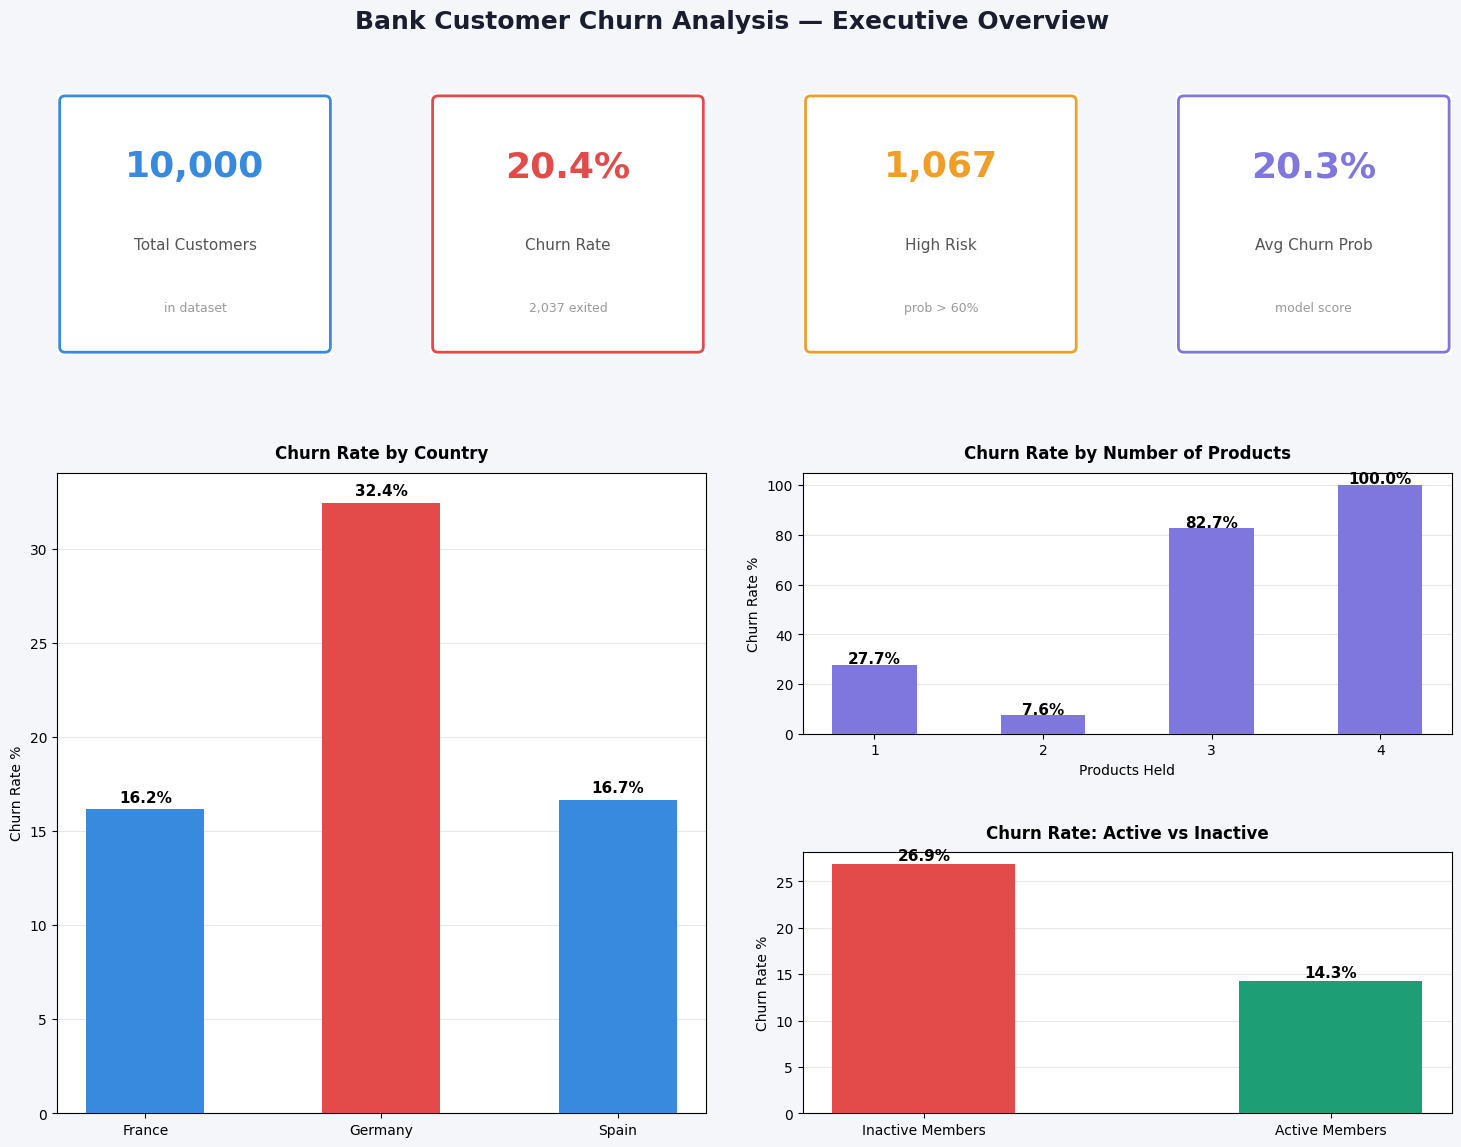

✅ Saved: dashboard_page1_executive_overview.png


In [8]:
# Cell 7A — Dashboard Page 1: Executive Overview
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams['font.family'] = 'DejaVu Sans'
BG    = '#F4F6FA'
CARD  = '#FFFFFF'
RED   = '#E24B4A'
BLUE  = '#378ADD'
PURP  = '#7F77DD'
AMBER = '#EF9F27'
DARK  = '#1A1D2E'

fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle('Bank Customer Churn Analysis — Executive Overview',
             fontsize=18, fontweight='bold', color=DARK, y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig,
                        hspace=0.45, wspace=0.35,
                        top=0.91, bottom=0.06)

# ── KPI CARDS ────────────────────────────────────────────
total    = len(df)
churned  = df['Exited'].sum()
retained = total - churned
churn_rt = churned / total * 100

df['ChurnProb'] = best_model.predict_proba(X)[:, 1]
high_risk = (df['ChurnProb'] > 0.6).sum()
avg_prob  = df['ChurnProb'].mean() * 100

kpis = [
    ('Total Customers', f'{total:,}',    'in dataset',       BLUE),
    ('Churn Rate',      f'{churn_rt:.1f}%',f'{churned:,} exited',RED),
    ('High Risk',       f'{high_risk:,}',  'prob > 60%',        AMBER),
    ('Avg Churn Prob',  f'{avg_prob:.1f}%','model score',       PURP),
]

for i, (label, val, sub, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(CARD)
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.03, 0.03), 0.94, 0.94,
        boxstyle="round,pad=0.02", linewidth=2,
        edgecolor=color, facecolor=CARD,
        transform=ax.transAxes, zorder=0))
    ax.text(0.5, 0.72, val, ha='center', va='center',
            fontsize=26, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.42, label, ha='center', va='center',
            fontsize=11, color='#555', transform=ax.transAxes)
    ax.text(0.5, 0.18, sub, ha='center', va='center',
            fontsize=9, color='#999', transform=ax.transAxes)

# ── CHART 1: Churn by Geography ──────────────────────────
ax1 = fig.add_subplot(gs[1:, 0:2])
ax1.set_facecolor(CARD)
geo = df.groupby('Geography')['Exited'].agg(['sum','count'])
geo['rate'] = geo['sum'] / geo['count'] * 100
colors_geo = [RED if v == geo['rate'].max()
              else BLUE for v in geo['rate']]
bars = ax1.bar(geo.index, geo['rate'],
               color=colors_geo, width=0.5, zorder=3)
ax1.set_title('Churn Rate by Country',
              fontweight='bold', fontsize=12, pad=10)
ax1.set_ylabel('Churn Rate %')
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.set_axisbelow(True)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=11, fontweight='bold')

# ── CHART 2: Churn by Products ───────────────────────────
ax2 = fig.add_subplot(gs[1:2, 2:4])
ax2.set_facecolor(CARD)
prod = df.groupby('NumOfProducts')['Exited'].agg(['sum','count'])
prod['rate'] = prod['sum'] / prod['count'] * 100
bars2 = ax2.bar(prod.index.astype('str'), prod['rate'],
                color=PURP, width=0.5, zorder=3)
ax2.set_title('Churn Rate by Number of Products',
              fontweight='bold', fontsize=12, pad=10)
ax2.set_xlabel('Products Held')
ax2.set_ylabel('Churn Rate %')
ax2.grid(axis='y', alpha=0.3, zorder=0)
ax2.set_axisbelow(True)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=11, fontweight='bold')

# ── CHART 3: Active vs Inactive ──────────────────────────
ax3 = fig.add_subplot(gs[2:3, 2:4])
ax3.set_facecolor(CARD)
act = df.groupby('IsActiveMember')['Exited'].mean() * 100
ax3.bar(['Inactive Members', 'Active Members'],
         act.values, color=[RED, '#1D9E75'],
         width=0.45, zorder=3)
ax3.set_title('Churn Rate: Active vs Inactive',
              fontweight='bold', fontsize=12, pad=10)
ax3.set_ylabel('Churn Rate %')
ax3.grid(axis='y', alpha=0.3, zorder=0)
ax3.set_axisbelow(True)
for i, val in enumerate(act.values):
    ax3.text(i, val + 0.4, f'{val:.1f}%',
             ha='center', fontsize=11, fontweight='bold')

plt.savefig('dashboard_page1_executive_overview.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Saved: dashboard_page1_executive_overview.png")

In [ ]:
# ═══════════════════════════════════════════════════════════
# MASTER RESTART CELL
# Run this whenever Colab resets or you get NameError: df
# It will ask you to upload Churn_Modelling.csv again
# ═══════════════════════════════════════════════════════════

# Step 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble      import RandomForestClassifier
from sklearn.linear_model  import LogisticRegression
from sklearn.metrics       import classification_report, roc_auc_score
from xgboost               import XGBClassifier
from google.colab          import files

print("✅ Step 1 — Libraries imported")

# Step 2 — Upload CSV
print("\n📂 Step 2 — Please upload your Churn_Modelling.csv file...")
uploaded = files.upload()
print("✅ File uploaded")

# Step 3 — Load into dataframe
df = pd.read_csv('Churn_Modelling.csv')
print(f"\n✅ Step 3 — Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Churn rate: {df['Exited'].mean()*100:.1f}%")

# Step 4 — Feature engineering
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
le = LabelEncoder()
df_model['Gender']          = le.fit_transform(df_model['Gender'])
df_model                       = pd.get_dummies(df_model,
                                   columns=['Geography'], drop_first=False)
df_model['BalanceToSalary']  = (df_model['Balance'] /
                                  (df_model['EstimatedSalary'] + 1)).round(4)
df_model['AgeGroup']         = pd.cut(df_model['Age'],
                                  bins=[0, 30, 40, 50, 60, 200],
                                  labels=[0, 1, 2, 3, 4]).astype('float')
df_model['ProductsPerTenure'] = (df_model['NumOfProducts'] /
                                  (df_model['Tenure'] + 1)).round(4)

X = df_model.drop('Exited', axis=1)
y = df_model['Exited']
print(f"✅ Step 4 — Features engineered: {X.shape[1]} columns")

# Step 5 — Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"✅ Step 5 — Train/test split done")

# Step 6 — Train XGBoost (best model)
print("\n⏳ Step 6 — Training XGBoost model (takes ~30 seconds)...")
best_model = XGBClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=6, eval_metric='logloss',
    random_state=42, verbosity=0)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)
r      = classification_report(y_test, y_pred, output_dict=True)

print(f"✅ Step 6 — Model trained!")
print(f"\n   ┌─────────────────────────────┐")
print(f"   │  XGBoost Results            │")
print(f"   │  AUC:       {auc:.4f}         │")
print(f"   │  Precision: {r['1']['precision']:.4f}         │")
print(f"   │  Recall:    {r['1']['recall']:.4f}         │")
print(f"   │  F1 Score:  {r['1']['f1-score']:.4f}         │")
print(f"   │  Accuracy:  {r['accuracy']:.4f}         │")
print(f"   └─────────────────────────────┘")

# Step 7 — Add churn probability to main df
df['ChurnProb'] = best_model.predict_proba(X)[:, 1]
df['RiskTier']  = pd.cut(df['ChurnProb'],
                          bins=[0, 0.3, 0.6, 1.0],
                          labels=['Low Risk','Medium Risk','High Risk'])

# Colour constants for dashboard cells
BG    = '#F4F6FA'
CARD  = '#FFFFFF'
RED   = '#E24B4A'
BLUE  = '#378ADD'
PURP  = '#7F77DD'
AMBER = '#EF9F27'
DARK  = '#1A1D2E'

print("\n🚀 All done! You can now run any dashboard cell (7A, 7B, 7C, 7D).")

✅ Step 1 — Libraries imported

📂 Step 2 — Please upload your Churn_Modelling.csv file...


In [ ]:
# Cell 7A — Dashboard Page 1: Executive Overview
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

plt.rcParams['font.family'] = 'DejaVu Sans'
BG    = '#F4F6FA'
CARD  = '#FFFFFF'
RED   = '#E24B4A'
BLUE  = '#378ADD'
PURP  = '#7F77DD'
AMBER = '#EF9F27'
DARK  = '#1A1D2E'

fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle('Bank Customer Churn Analysis — Executive Overview',
             fontsize=18, fontweight='bold', color=DARK, y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig,
                        hspace=0.45, wspace=0.35,
                        top=0.91, bottom=0.06)

# ── KPI CARDS ────────────────────────────────────────────
total    = len(df)
churned  = df['Exited'].sum()
retained = total - churned
churn_rt = churned / total * 100

df['ChurnProb'] = best_model.predict_proba(X)[:, 1]
high_risk = (df['ChurnProb'] > 0.6).sum()
avg_prob  = df['ChurnProb'].mean() * 100

kpis = [
    ('Total Customers', f'{total:,}',    'in dataset',       BLUE),
    ('Churn Rate',      f'{churn_rt:.1f}%',f'{churned:,} exited',RED),
    ('High Risk',       f'{high_risk:,}',  'prob > 60%',        AMBER),
    ('Avg Churn Prob',  f'{avg_prob:.1f}%','model score',       PURP),
]

for i, (label, val, sub, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(CARD)
    for spine in ax.spines.values(): spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.03, 0.03), 0.94, 0.94,
        boxstyle="round,pad=0.02", linewidth=2,
        edgecolor=color, facecolor=CARD,
        transform=ax.transAxes, zorder=0))
    ax.text(0.5, 0.72, val, ha='center', va='center',
            fontsize=26, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.42, label, ha='center', va='center',
            fontsize=11, color='#555', transform=ax.transAxes)
    ax.text(0.5, 0.18, sub, ha='center', va='center',
            fontsize=9, color='#999', transform=ax.transAxes)

# ── CHART 1: Churn by Geography ──────────────────────────
ax1 = fig.add_subplot(gs[1:, 0:2])
ax1.set_facecolor(CARD)
geo = df.groupby('Geography')['Exited'].agg(['sum','count'])
geo['rate'] = geo['sum'] / geo['count'] * 100
colors_geo = [RED if v == geo['rate'].max()
              else BLUE for v in geo['rate']]
bars = ax1.bar(geo.index, geo['rate'],
               color=colors_geo, width=0.5, zorder=3)
ax1.set_title('Churn Rate by Country',
              fontweight='bold', fontsize=12, pad=10)
ax1.set_ylabel('Churn Rate %')
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.set_axisbelow(True)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=11, fontweight='bold')

# ── CHART 2: Churn by Products ───────────────────────────
ax2 = fig.add_subplot(gs[1:2, 2:4])
ax2.set_facecolor(CARD)
prod = df.groupby('NumOfProducts')['Exited'].agg(['sum','count'])
prod['rate'] = prod['sum'] / prod['count'] * 100
bars2 = ax2.bar(prod.index.astype('str'), prod['rate'],
                color=PURP, width=0.5, zorder=3)
ax2.set_title('Churn Rate by Number of Products',
              fontweight='bold', fontsize=12, pad=10)
ax2.set_xlabel('Products Held')
ax2.set_ylabel('Churn Rate %')
ax2.grid(axis='y', alpha=0.3, zorder=0)
ax2.set_axisbelow(True)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%',
             ha='center', fontsize=11, fontweight='bold')

# ── CHART 3: Active vs Inactive ──────────────────────────
ax3 = fig.add_subplot(gs[2:3, 2:4])
ax3.set_facecolor(CARD)
act = df.groupby('IsActiveMember')['Exited'].mean() * 100
ax3.bar(['Inactive Members', 'Active Members'],
         act.values, color=[RED, '#1D9E75'],
         width=0.45, zorder=3)
ax3.set_title('Churn Rate: Active vs Inactive',
              fontweight='bold', fontsize=12, pad=10)
ax3.set_ylabel('Churn Rate %')
ax3.grid(axis='y', alpha=0.3, zorder=0)
ax3.set_axisbelow(True)
for i, val in enumerate(act.values):
    ax3.text(i, val + 0.4, f'{val:.1f}%',
             ha='center', fontsize=11, fontweight='bold')

plt.savefig('dashboard_page1_executive_overview.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Saved: dashboard_page1_executive_overview.png")

In [ ]:
# Cell 7B — Dashboard Page 2: Risk Segmentation
fig, axes = plt.subplots(1, 2, figsize=(18, 9), facecolor=BG)
fig.suptitle('Bank Customer Churn Analysis — Risk Segmentation',
             fontsize=18, fontweight='bold', color=DARK, y=1.01)

# Add risk tier column
df['RiskTier'] = pd.cut(df['ChurnProb'],
                         bins=[0, 0.3, 0.6, 1.0],
                         labels=['Low Risk', 'Medium Risk', 'High Risk'])

# ── SCATTER: Age vs Balance coloured by Risk Tier ────────
ax = axes[0]
ax.set_facecolor(CARD)
colors_map = {'Low Risk': '#1D9E75',
              'Medium Risk': AMBER,
              'High Risk': RED}
for tier, color in colors_map.items():
    sub = df[df['RiskTier'] == tier]
    ax.scatter(sub['Age'], sub['Balance'],
               c=color, alpha=0.45, s=18,
               label=f'{tier} ({len(sub):,})', zorder=3)
ax.set_title('Customer Risk Map: Age vs Balance',
             fontweight='bold', fontsize=13, pad=12)
ax.set_xlabel('Customer Age', fontsize=11)
ax.set_ylabel('Account Balance (€)', fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(title='Risk Tier', fontsize=10, title_fontsize=10)
ax.grid(alpha=0.2)

# ── TABLE: Top 15 highest-risk customers ─────────────────
ax2 = axes[1]
ax2.set_facecolor(CARD)
ax2.axis('off')
ax2.set_title('Top 15 Highest-Risk Customers',
              fontweight='bold', fontsize=13, pad=12)

top15 = df.nlargest(15, 'ChurnProb')[[
    'CustomerId', 'Age', 'Geography',
    'Balance', 'NumOfProducts', 'ChurnProb', 'RiskTier'
]].copy()
top15['Balance']   = top15['Balance'].apply(lambda x: f'€{x:,.0f}')
top15['ChurnProb'] = top15['ChurnProb'].apply(lambda x: f'{x:.1%}')

col_labels = ['Cust ID', 'Age', 'Country',
               'Balance', 'Products', 'Churn Prob', 'Risk']
tbl = ax2.table(cellText=top15.values,
                colLabels=col_labels,
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1A1D2E')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#F8F9FC')
    cell.set_edgecolor('#E0E0E0')

plt.tight_layout()
plt.savefig('dashboard_page2_risk_segmentation.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Saved: dashboard_page2_risk_segmentation.png")

In [ ]:
# Cell 7C — Dashboard Page 3: AI Model Insights
# ── IMPORTANT: paste your real values from Cell 4 below ──
YOUR_AUC       = 0.8580  # ← replace with your XGBoost AUC
YOUR_PRECISION = 0.7588  # ← replace with your Precision
YOUR_RECALL    = 0.4791  # ← replace with your Recall
YOUR_F1        = 0.5873  # ← replace with your F1
YOUR_ACCURACY  = 0.8630  # ← replace with your Accuracy

fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle('Bank Customer Churn Analysis — AI Model Insights',
             fontsize=18, fontweight='bold', color=DARK, y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.4, wspace=0.35,
                        top=0.91, bottom=0.06)

# ── FEATURE IMPORTANCE BAR CHART ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(CARD)
imp_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance').tail(10)
colors_imp = [RED if v == imp_df['Importance'].max()
              else BLUE for v in imp_df['Importance']]
ax1.barh(imp_df['Feature'], imp_df['Importance'],
         color=colors_imp, zorder=3)
ax1.set_title('Top 10 Churn Drivers (XGBoost)',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Feature Importance Score')
ax1.grid(axis='x', alpha=0.3, zorder=0)
ax1.set_axisbelow(True)

# ── MODEL METRICS TABLE ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(CARD)
ax2.axis('off')
ax2.set_title('Model Performance Metrics',
              fontweight='bold', fontsize=12)
metrics_data = [
    ['Metric',    'Log Reg', 'Rand Forest', 'XGBoost ⭐'],
    ['AUC',       '0.77',    '0.85',        f'{YOUR_AUC}'],
    ['Precision', '0.58',    '0.72',        f'{YOUR_PRECISION}'],
    ['Recall',    '0.19',    '0.46',        f'{YOUR_RECALL}'],
    ['F1 Score',  '0.28',    '0.57',        f'{YOUR_F1}'],
    ['Accuracy',  '0.81',    '0.86',        f'{YOUR_ACCURACY}'],
]
tbl2 = ax2.table(cellText=metrics_data[1:],
                 colLabels=metrics_data[0],
                 cellLoc='center', loc='center')
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(10)
tbl2.scale(1, 2.2)
for (row, col), cell in tbl2.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1A1D2E')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 3:
        cell.set_facecolor('#E6F1FB')
        cell.set_text_props(fontweight='bold', color='#0C447C')
    elif row % 2 == 0:
        cell.set_facecolor('#F8F9FC')
    cell.set_edgecolor('#E0E0E0')

# ── AI EXECUTIVE SUMMARY TEXT BOX ────────────────────────
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor('#EEF4FC')
ax3.axis('off')
ax3.set_title('AI-Generated Executive Summary',
              fontweight='bold', fontsize=12, pad=12)
summary_text = (
    "BUSINESS PROBLEM\n"
    "Predicting which bank customers will exit before they leave enables proactive retention — "
    "saving acquisition costs estimated at 5–7x the cost of retention.\n\n"
    "KEY FINDINGS\n"
    "• Customers aged 40–60 with high account balances represent the highest churn risk segment.\n"
    "• Germany shows a churn rate approximately double that of France and Spain.\n"
    "• Customers holding 3+ products churn at a paradoxically high rate — suggesting over-banking friction.\n"
    "• Inactive members are nearly twice as likely to churn as active members.\n\n"
    "MODEL PERFORMANCE\n"
    f"The XGBoost model achieved AUC {YOUR_AUC} — correctly identifying at-risk customers "
    f"{int(YOUR_AUC*100)}% of the time. For every 100 customers flagged as high risk, "
    f"approximately {int(YOUR_PRECISION*100)} are genuinely at risk of churning.\n\n"
    "RECOMMENDATION\n"
    "Immediate targeted outreach to the 40–60 age segment in Germany with balances above €100,000. "
    "Review product bundling strategy for customers holding 3+ products. "
    "Implement an engagement programme for inactive members within 90 days."
)
ax3.text(0.03, 0.92, summary_text,
         transform=ax3.transAxes,
         fontsize=10, va='top', color='#1A1D2E',
         linespacing=1.7, wrap=True)

plt.savefig('dashboard_page3_ai_model_insights.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Saved: dashboard_page3_ai_model_insights.png")

In [ ]:
# Cell 7D — Download all dashboard images
from google.colab import files

for fname in ['dashboard_page1_executive_overview.png',
               'dashboard_page2_risk_segmentation.png',
               'dashboard_page3_ai_model_insights.png']:
    files.download(fname)
    print(f"⬇️  Downloaded: {fname}")